import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Đọc dữ liệu
df = pd.read_csv("vix_features_1D_updated.csv")
if 'time' in df.columns:
    df = df.drop(columns=['time'])

# 2. Tính Log Returns
df['log_return'] = np.log(df['close'] / df['close'].shift(1))
df = df.dropna().reset_index(drop=True)

# THÊM MỚI: Tạo nhãn xu hướng (1: Tăng, 0: Giảm)
# Nếu log_return > 0 nghĩa là giá tăng so với hôm qua
df['target_direction'] = (df['log_return'] > 0).astype(int)

# Tách Features (đặc trưng) và Target (mục tiêu)
features = df.drop(columns=['target_direction']).values
target = df['target_direction'].values

# 3. Chia tập dữ liệu (80/20)
split_index = int(len(features) * 0.8)
X_train_raw = features[:split_index]
X_val_raw = features[split_index:]

y_train_raw = target[:split_index]
y_val_raw = target[split_index:]

# 4. Chuẩn hóa dữ liệu (CHỈ chuẩn hóa Features, không chuẩn hóa nhãn 0/1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_val_scaled = scaler.transform(X_val_raw)

# 5. Kỹ thuật Sliding Window
def create_sequences(X_data, y_data, time_steps=10):
    X, y = [], []
    for i in range(len(X_data) - time_steps):
        X.append(X_data[i : (i + time_steps)])          
        y.append(y_data[i + time_steps])  # Lấy nhãn 0/1 của ngày T+1
    return np.array(X), np.array(y)

time_steps = 10
X_train, y_train = create_sequences(X_train_scaled, y_train_raw, time_steps)
X_val, y_val = create_sequences(X_val_scaled, y_val_raw, time_steps)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")

✅ X_train shape: (1955, 14), y_train shape: (1955,)
✅ X_val shape: (489, 14), y_val shape: (489,)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# =========================================================
# 1. TÍNH TOÁN TRỌNG SỐ CHO CÁC NHÃN (XỬ LÝ MẤT CÂN BẰNG)
# =========================================================
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))
print(f"Trọng số áp dụng cho các nhãn (Class weights): {class_weight_dict}")

# =========================================================
# 2. KHỞI TẠO MÔ HÌNH (TINH GỌN ĐỂ CHỐNG OVERFITTING)
# =========================================================
model = Sequential()

# Lớp Input
model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))

# Lớp LSTM 1 (Giảm units xuống 32, tăng dropout lên 0.3)
model.add(LSTM(units=32, return_sequences=True))
model.add(Dropout(0.3)) 

# Lớp LSTM 2 (Giảm units xuống 16)
model.add(LSTM(units=16, return_sequences=False))
model.add(Dropout(0.3))

# Lớp Dense trung gian
model.add(Dense(units=16, activation='relu'))

# Lớp Output cho phân loại nhị phân
model.add(Dense(units=1, activation='sigmoid'))

# Biên dịch mô hình
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["accuracy"])

model.summary()

Trọng số áp dụng cho các nhãn (Class weights): {np.int64(0): np.float64(0.6915422885572139), np.int64(1): np.float64(1.8051948051948052)}


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 10, 16)         │         1,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 10, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 8)              │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15, 
    restore_best_weights=True, # Khôi phục lại trọng số của epoch tốt nhất
    verbose=1
)

# Lưu checkpoint dựa trên val_loss (tốt hơn val_accuracy khi dữ liệu mất cân bằng)
checkpoint = ModelCheckpoint(
    'timeseries_classification_best.keras', 
    monitor='val_loss', 
    save_best_only=True, 
    mode='min', 
    verbose=1
)

# =========================================================
# 4. TIẾN HÀNH HUẤN LUYỆN
# =========================================================
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    class_weight=class_weight_dict, # Đưa trọng số vào huấn luyện
    callbacks=[checkpoint, early_stopping],
    verbose=1
)

print("✅ Đã hoàn tất huấn luyện và lưu mô hình tối ưu nhất!")

Epoch 1/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.4486 - loss: 0.6930
Epoch 1: val_loss improved from None to 0.69223, saving model to timeseries_classification_best.keras

Epoch 1: finished saving model to timeseries_classification_best.keras
61/61 ━━━━━━━━━━━━━━━━━━━━ 46s 164ms/step - accuracy: 0.4486 - loss: 0.6930 - val_accuracy: 0.5470 - val_loss: 0.6922
Epoch 2/100
60/61 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5104 - loss: 0.6912
Epoch 2: val_loss improved from 0.69223 to 0.68297, saving model to timeseries_classification_best.keras

Epoch 2: finished saving model to timeseries_classification_best.keras
61/61 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.5139 - loss: 0.6917 - val_accuracy: 0.6263 - val_loss: 0.6830
Epoch 3/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5874 - loss: 0.6906
Epoch 3: val_loss improved from 0.68297 to 0.67992, saving model to timeseries_classification_best.keras

Epoch 3: finished saving model to timeseries_classi

In [33]:
# Lưu toàn bộ kiến trúc mạng, trọng số và optimizer
model.save("timeseries_model.keras") 
print("Đã lưu thành công mô hình Keras dạng")

Đã lưu thành công mô hình Keras dạng



KẾT QUẢ ĐÁNH GIÁ XGBOOST
Accuracy: 64.01%

--- Báo cáo chi tiết ---
              precision    recall  f1-score   support

    Giảm (0)       0.82      0.67      0.74       369
    Tăng (1)       0.35      0.55      0.43       120

    accuracy                           0.64       489
   macro avg       0.59      0.61      0.58       489
weighted avg       0.71      0.64      0.66       489



<Figure size 1000x600 with 0 Axes>

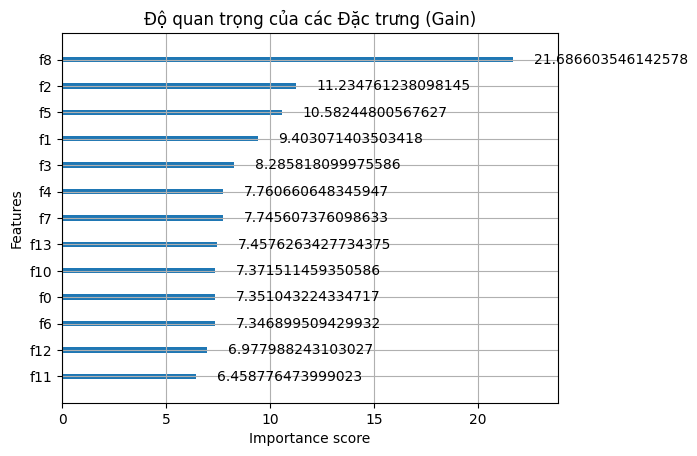

In [34]:
# 1. Dự đoán xác suất cho tập Validation
predicted_probs = model.predict(X_val)

# 2. Chuyển xác suất thành nhãn (Nếu xác suất > 0.5 -> Đoán Tăng (1), ngược lại Giảm (0))
predicted_labels = (predicted_probs > 0.5).astype(int).flatten()

# 3. Tính toán các chỉ số
acc = accuracy_score(y_val, predicted_labels)

print("="*40)
print("KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH (CLASSIFICATION)")
print("="*40)
print(f"Accuracy (Độ chính xác tổng thể): {acc * 100:.2f}%\n")

print("--- Báo cáo chi tiết ---")
print(classification_report(y_val, predicted_labels, target_names=["Giảm (0)", "Tăng (1)"]))

# 4. Vẽ Confusion Matrix (Ma trận nhầm lẫn)
cm = confusion_matrix(y_val, predicted_labels)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=["Đoán Giảm", "Đoán Tăng"], 
            yticklabels=["Thực Giảm", "Thực Tăng"])
plt.title('Ma trận nhầm lẫn (Confusion Matrix)')
plt.ylabel('Thực tế')
plt.xlabel('Dự đoán')
plt.show()

In [35]:
import joblib

# ✅ Lưu scaler
joblib.dump(scaler, 'scaler_FINAL.pkl')
print("✅ Scaler saved: scaler_FINAL.pkl")

# ✅ Tải lại scaler
scaler = joblib.load('scaler_FINAL.pkl')
print("✅ Scaler loaded!")

✅ Scaler saved: scaler_FINAL.pkl
✅ Scaler loaded!


In [36]:
import joblib
import pickle

# Thay tên file và đuôi file (.pkl, .save, .joblib...) cho đúng với file của bạn
FILE_PATH = "scaler_final.pkl" 

def inspect_scaler(file_path):
    print(f"Đang kiểm tra file: {file_path}")
    print("-" * 40)
    
    # Thử load file (thường dùng joblib hoặc pickle)
    try:
        data = joblib.load(file_path)
    except Exception as e1:
        try:
            with open(file_path, 'rb') as f:
                data = pickle.load(f)
        except Exception as e2:
            print("Không thể load file bằng joblib hay pickle. Lỗi:")
            print(f"Joblib error: {e1}")
            print(f"Pickle error: {e2}")
            return

    # 1. In ra kiểu dữ liệu tổng thể
    print(f"👉 Kiểu dữ liệu gốc (Type): {type(data)}\n")

    # 2. Bóc tách nội dung dựa trên kiểu dữ liệu
    if isinstance(data, dict):
        print("👉 Đây là một Dictionary (thường chứa nhiều Scaler).")
        print(f"Các keys bên trong: {list(data.keys())}")
        for key, value in data.items():
            print(f"  - Key '{key}' chứa object kiểu: {type(value)}")
            
    elif isinstance(data, (list, tuple)):
        print(f"👉 Đây là một {type(data).__name__} (Danh sách/Tuple).")
        print(f"Số lượng phần tử: {len(data)}")
        for i, item in enumerate(data):
            print(f"  - Phần tử {i}: {type(item)}")
            
    elif "sklearn" in str(type(data)):
        print("👉 Đây là một Scaler object trực tiếp duy nhất.")
        print(f"Loại Scaler: {data}")
        # In thử vài thông số của Scaler để xác nhận nó đã được fit
        if hasattr(data, 'data_min_'):
            print(f"  - Data Min: {data.data_min_}")
            print(f"  - Data Max: {data.data_max_}")
    else:
        print("👉 Dữ liệu không xác định cấu trúc chuẩn:")
        print(data)

if __name__ == "__main__":
    inspect_scaler(FILE_PATH)

Đang kiểm tra file: scaler_final.pkl
----------------------------------------
👉 Kiểu dữ liệu gốc (Type): <class 'sklearn.preprocessing._data.StandardScaler'>

👉 Đây là một Scaler object trực tiếp duy nhất.
Loại Scaler: StandardScaler()
